# 【第４回 課題７】 画像生成: Stable Diffusion

## 実施内容
1. **3種類のモデル**で，それぞれ**日本語 1枚 + 英語 1枚**の画像を生成（合計6枚）
2. **画像をプロンプトで修正する方法（img2img）** を実施（２画像）
3. **画像とマスク画像で指定部分を書き換える方法（inpainting）** を 実施（２画像）

## 使用モデル
| モデル名 | リポジトリ | 特徴 |
|---|---|---|
| **Stable Diffusion 2.1** | `stabilityai/stable-diffusion-2-1` | SD 2.1-base の上位版・768px 対応 |
| **SDXL-Turbo** | `stabilityai/sdxl-turbo` | 少ステップで高速生成 |
| **SDXL Base 1.0** | `stabilityai/stable-diffusion-xl-base-1.0` | 高解像度・高品質の標準 XL モデル |

> **SD 2.1-base の代替について**  
> 元の `stabilityai/stable-diffusion-2-1-base` の代わりに，
> **Stable Diffusion 2.1**（`stabilityai/stable-diffusion-2-1`）を使用します．  
> SD 2.1 は SD 2.1-base の上位版で，解像度が 512px → **768px** になり品質が向上します．
> 同じ `StableDiffusionPipeline` でそのまま動作します．

In [1]:
import sys
print(sys.executable)

/home/yanai-lab/oyundari/miniconda3/envs/sd/bin/python


## 環境設定
GPU の選択と Hugging Face キャッシュの保存先を設定します．

In [2]:
import os

# 使用する GPU を番号で指定（空いているものを選ぶ）
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# Hugging Face のキャッシュを書き込み可能な場所に設定
_HF_CACHE = "/export/space0/oyundari/hf_cache"
os.environ["HF_HOME"]               = _HF_CACHE
os.environ["HUGGINGFACE_HUB_CACHE"] = os.path.join(_HF_CACHE, "hub")
os.environ["TRANSFORMERS_CACHE"]    = os.path.join(_HF_CACHE, "transformers")
os.environ["DIFFUSERS_CACHE"]       = os.path.join(_HF_CACHE, "diffusers")

for path in os.environ["HF_HOME"], os.environ["HUGGINGFACE_HUB_CACHE"]:
    os.makedirs(path, exist_ok=True)

print("HF_HOME            =", os.environ["HF_HOME"])
print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

HF_HOME            = /export/space0/oyundari/hf_cache
CUDA_VISIBLE_DEVICES = 1


## ライブラリのインポートとユーティリティ関数の定義

In [3]:
%matplotlib inline

import gc
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from PIL import Image, ImageDraw

from diffusers import (
    StableDiffusionPipeline,
    AutoPipelineForText2Image,
    AutoPipelineForImage2Image,
    AutoPipelineForInpainting,
)

# デバイスと dtype の自動判定
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
print("DEVICE =", DEVICE)
print("DTYPE  =", DTYPE)

# 出力ディレクトリの作成
OUTDIR = Path("out")
OUTDIR.mkdir(parents=True, exist_ok=True)
print("OUTDIR =", OUTDIR)


# ─────────────────── ユーティリティ関数 ───────────────────

def clear_gpu(*objs):
    """指定オブジェクトを削除し GPU メモリを解放する．"""
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


def show_images(images, titles=None, figsize=(14, 5), suptitle=None):
    """複数画像を横一列で表示する．"""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def show_grid(images, titles=None, cols=3, figsize=(15, 10), suptitle=None):
    """複数画像をグリッド形式で表示する．"""
    n    = len(images)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.flat:
        ax.axis("off")
    for i, img in enumerate(images):
        r, c = divmod(i, cols)
        axes[r, c].imshow(img)
        axes[r, c].axis("off")
        if titles is not None:
            axes[r, c].set_title(titles[i], fontsize=10)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def show_before_after(before, after, mask=None,
                      before_title="Before", after_title="After",
                      mask_title="Mask", suptitle=None):
    """Before / Mask（省略可）/ After を並べて表示する．"""
    items = [(before, before_title)]
    if mask is not None:
        items.append((mask, mask_title))
    items.append((after, after_title))

    n = len(items)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (img, title) in zip(axes, items):
        if img.mode == "L":
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def save_image(img, filename):
    """画像を OUTDIR に保存し，パスを返す．"""
    path = OUTDIR / filename
    img.save(path)
    print(f"  保存完了: {path}")
    return path


def make_polygon_mask(size, points):
    """多角形マスクを作成する（白=書き換え領域，黒=保持領域）．"""
    mask = Image.new("L", size, 0)
    ImageDraw.Draw(mask).polygon(points, fill=255)
    return mask


def make_rect_mask(size, box):
    """矩形マスクを作成する．box = (x0, y0, x1, y1)．"""
    mask = Image.new("L", size, 0)
    ImageDraw.Draw(mask).rectangle(box, fill=255)
    return mask


/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


DEVICE = cuda
DTYPE  = torch.float16
OUTDIR = out


## プロキシ設定と Hugging Face ログイン

In [4]:
import os

# 学内ネットワーク経由の場合はプロキシを設定
os.environ["http_proxy"]  = "http://proxy.uec.ac.jp:8080/"
os.environ["https_proxy"] = "http://proxy.uec.ac.jp:8080/"

# IPv6 を無効化（接続問題の回避）
os.environ["HF_HUB_DISABLE_IPV6"] = "1"

In [5]:
from huggingface_hub import login

# Hugging Face アクセストークンでログイン
# ※ トークンは https://huggingface.co/settings/tokens で取得してください
login("-")

---
# 課題 7-1　テキストから画像を生成（text-to-image）

**3種類のモデル**で，それぞれ **日本語プロンプト 1枚 + 英語プロンプト 1枚** を生成します（合計 6 枚）．

### プロンプト一覧
| # | モデル | 日本語プロンプト | 英語プロンプト |
|---|---|---|---|
| 1 | Stable Diffusion 2.1 | 満開の桜並木，夕暮れ，水面に映る反射，幻想的 | A moonlit ancient Japanese temple surrounded by bamboo forest, cinematic |
| 2 | SDXL-Turbo | サイバーパンクな東京の夜，ネオンサイン，雨，反射 | A futuristic robot samurai in neon-lit Tokyo alley, high detail |
| 3 | SDXL Base 1.0 | 深海の神秘的なクラゲ，青い光，泡，超高精細 | Breathtaking aurora borealis over a snowy mountain lake, ultra HD |

In [9]:
# ─── モデル設定リスト ───

MODEL_SPECS = [
    {
        "name": "sd_v15",
        "title": "Stable Diffusion v1.5",
        "repo": "stable-diffusion-v1-5/stable-diffusion-v1-5",
        "kind": "sd15",
        "jp_prompt" : "ふわふわした白い猫が木の床の上に座っている、大きな青い目、柔らかな照明、フォトリアル",
        "en_prompt" : "a shiny red sports car parked on a mountain road, photorealistic, high detail",
    },
    {
        "name"      : "sdxl_turbo",
        "title"     : "SDXL-Turbo",
        "repo"      : "stabilityai/sdxl-turbo",
        "kind"      : "turbo",
        "jp_prompt" : "緑のサバンナに立つ威厳のある象、ゴールデンアワーの光、フォトリアル",
        "en_prompt" : "a basket of colorful fresh fruits on a wooden table, photorealistic, high detail",
    },
    {
        "name"      : "sdxl_base",
        "title"     : "SDXL Base 1.0",
        "repo"      : "stabilityai/stable-diffusion-xl-base-1.0",
        "kind"      : "sdxl",
        "jp_prompt" : "山岳の谷の上空を飛ぶハクトウワシ、翼を大きく広げている、フォトリアル",
        "en_prompt" : "a classic wooden violin resting on a velvet cloth, detailed texture, photorealistic",
    },
]


def load_t2i_pipe(spec):
    """spec に応じて text-to-image パイプラインをロードする．"""
    common = dict(
        torch_dtype=DTYPE,
        cache_dir=os.environ["HF_HOME"],
        token=True,
    )
    if spec["kind"] == "sd15":
        pipe = StableDiffusionPipeline.from_pretrained(spec["repo"], **common)
    elif spec["kind"] == "turbo":
        pipe = AutoPipelineForText2Image.from_pretrained(
            spec["repo"], variant="fp16" if DEVICE == "cuda" else None, **common)
    else:  # sdxl
        pipe = AutoPipelineForText2Image.from_pretrained(
            spec["repo"],
            variant="fp16" if DEVICE == "cuda" else None,
            use_safetensors=True, **common)
    pipe.enable_attention_slicing()
    if hasattr(pipe, 'enable_vae_slicing'):
        pipe.enable_vae_slicing()
    pipe.enable_model_cpu_offload()
    return pipe

In [10]:
plt.rcParams['font.family'] = 'Noto Sans CJK JP'

▶ モデルロード中: Stable Diffusion v1.5  (stable-diffusion-v1-5/stable-diffusion-v1-5）


Loading pipeline components...: 100%|██████████| 7/7 [08:28<00:00, 72.69s/it]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


  ロード完了: 514.4s
  [jp] プロンプト: ふわふわした白い猫が木の床の上に座っている、大きな青い目、柔らかな照明、フォトリアル


100%|██████████| 30/30 [00:04<00:00,  6.39it/s]


  保存完了: out/task1_sd_v15_jp.png
  生成時間: 7.6s
  [en] プロンプト: a shiny red sports car parked on a mountain road, photoreali...


100%|██████████| 30/30 [00:03<00:00,  8.90it/s]


  保存完了: out/task1_sd_v15_en.png
  生成時間: 4.5s


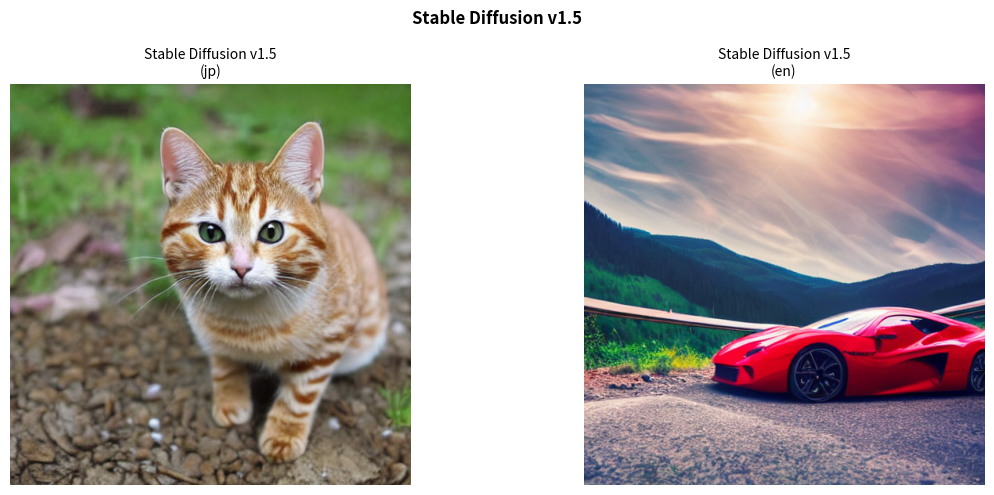


▶ モデルロード中: SDXL-Turbo  (stabilityai/sdxl-turbo）


/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:35<00:00,  5.05s/it]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


  ロード完了: 45.3s
  [jp] プロンプト: 緑のサバンナに立つ威厳のある象、ゴールデンアワーの光、フォトリアル


100%|██████████| 4/4 [03:16<00:00, 49.04s/it] 
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  保存完了: out/task1_sdxl_turbo_jp.png
  生成時間: 267.6s
  [en] プロンプト: a basket of colorful fresh fruits on a wooden table, photore...


100%|██████████| 4/4 [00:01<00:00,  2.01it/s]


  保存完了: out/task1_sdxl_turbo_en.png
  生成時間: 4.3s


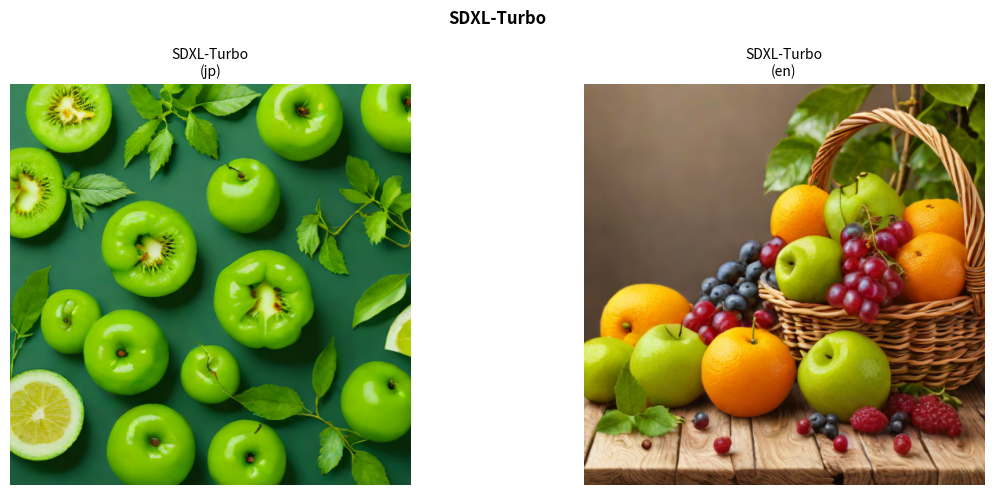


▶ モデルロード中: SDXL Base 1.0  (stabilityai/stable-diffusion-xl-base-1.0）


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.19it/s]


  ロード完了: 4.7s
  [jp] プロンプト: 山岳の谷の上空を飛ぶハクトウワシ、翼を大きく広げている、フォトリアル


100%|██████████| 30/30 [00:16<00:00,  1.87it/s]


  保存完了: out/task1_sdxl_base_jp.png
  生成時間: 19.7s
  [en] プロンプト: a classic wooden violin resting on a velvet cloth, detailed ...


100%|██████████| 30/30 [00:16<00:00,  1.85it/s]


  保存完了: out/task1_sdxl_base_en.png
  生成時間: 19.0s


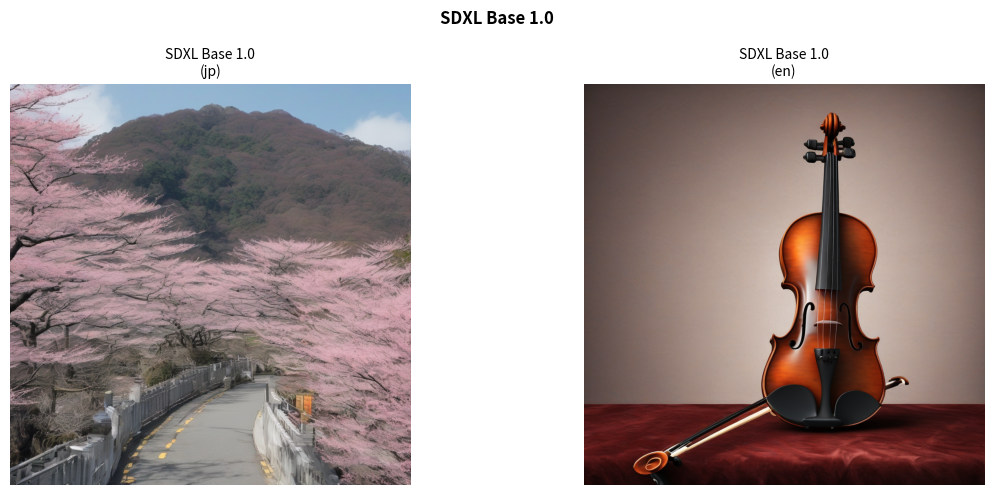

In [11]:
# ─── 6枚生成（各モデル: 日本語1枚 + 英語1枚）───

t2i_results = []  # 結果をまとめて保持するリスト

for spec in MODEL_SPECS:
    print("=" * 70)
    print(f"▶ モデルロード中: {spec['title']}  ({spec['repo']}）")
    t_start = time.time()
    pipe = load_t2i_pipe(spec)
    print(f"  ロード完了: {time.time() - t_start:.1f}s")

    imgs, titles = [], []

    for lang, prompt in [("jp", spec["jp_prompt"]), ("en", spec["en_prompt"])]:
        print(f"  [{lang}] プロンプト: {prompt[:60]}..." if len(prompt) > 60 else f"  [{lang}] プロンプト: {prompt}")

        t_gen = time.time()
        if spec["kind"] == "turbo":
            # SDXL-Turbo: ガイダンスなし・少ステップで高速生成
            img = pipe(prompt=prompt, guidance_scale=0.0, num_inference_steps=4).images[0]
        else:
            img = pipe(prompt=prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

        elapsed = time.time() - t_gen
        fname = f"task1_{spec['name']}_{lang}.png"
        save_image(img, fname)
        print(f"  生成時間: {elapsed:.1f}s")

        t2i_results.append(dict(model=spec["title"], lang=lang, prompt=prompt, path=str(OUTDIR / fname)))
        imgs.append(img)
        titles.append(f"{spec['title']}\n({lang})")

    # 2枚を横並びで表示
    show_images(imgs, titles=titles, figsize=(12, 5), suptitle=spec["title"])
    clear_gpu(pipe)
    print()

### 課題 7-1 まとめ表示（全6枚グリッド）

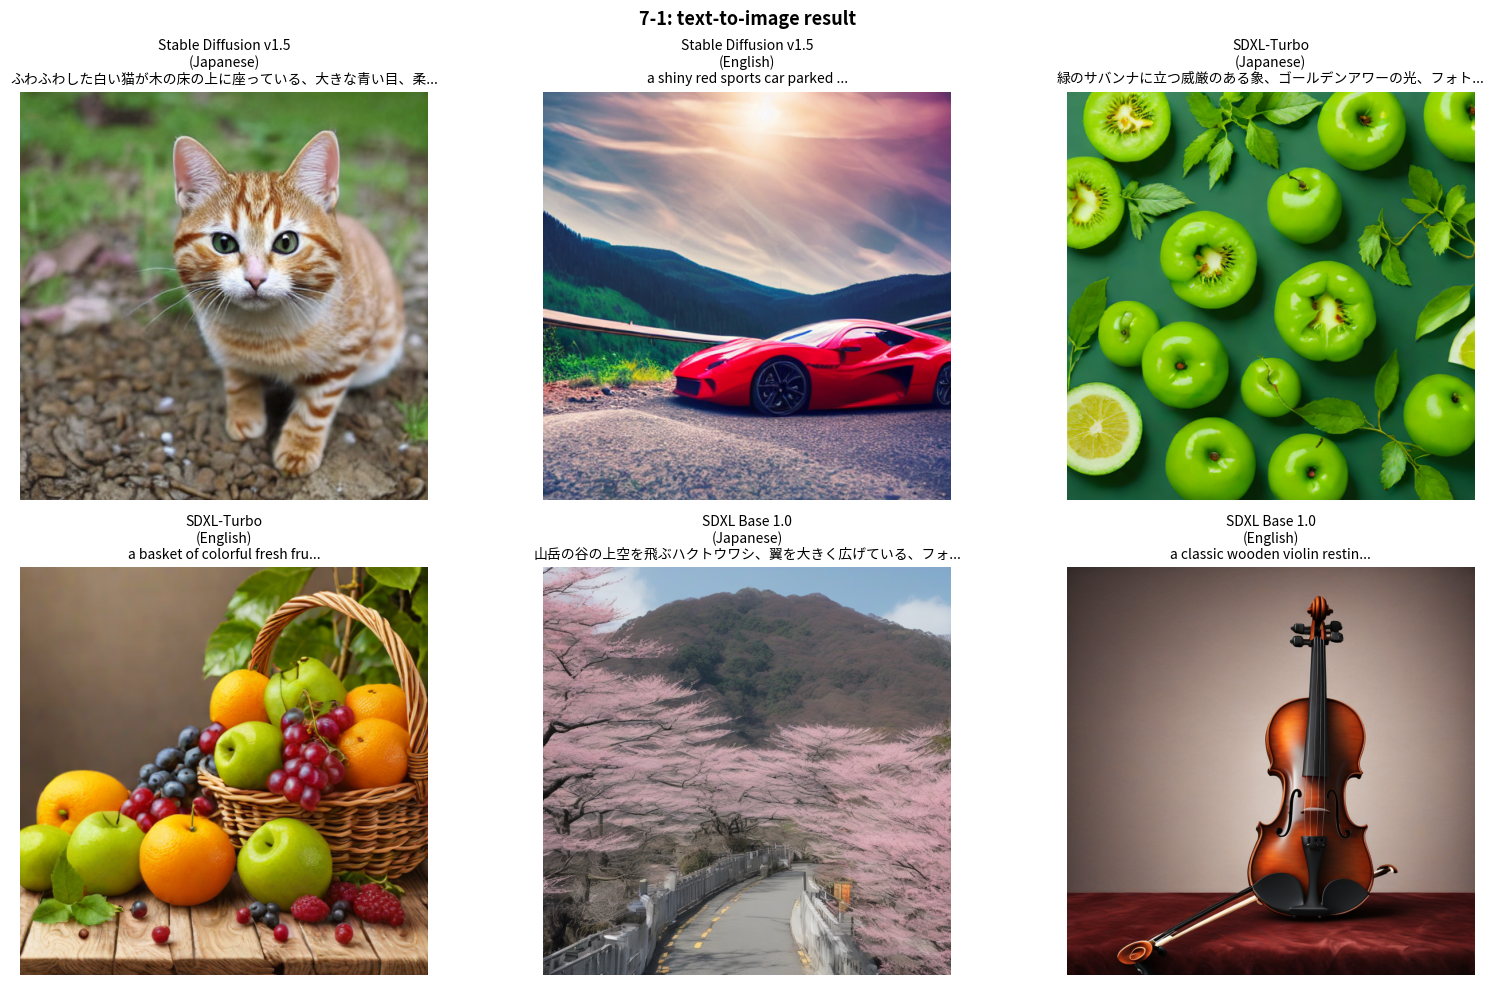

In [12]:
# ─── 全6枚を 2行×3列 のグリッドで表示 ───
all_imgs   = [Image.open(r["path"]).convert("RGB") for r in t2i_results]
all_titles = [
    f"{r['model']}\n({'Japanese' if r['lang']=='jp' else 'English'})\n{r['prompt'][:30]}..."
    if len(r['prompt']) > 30 else
    f"{r['model']}\n({'Jaapanese' if r['lang']=='jp' else 'English'})\n{r['prompt']}"
    for r in t2i_results
]

show_grid(all_imgs, titles=all_titles, cols=3, figsize=(16, 10),
          suptitle="7-1: text-to-image result")


---
# 課題 7-2 (1)　画像をプロンプトで修正（Image-to-Image）

**img2img** では，元画像とプロンプトの両方を入力として，  
プロンプトの内容に沿いながら元画像の構造を部分的に保ちつつ変換します．

- **`strength`** パラメータ（0〜1）で元画像の保持量を制御します．
  - 小さい（0.3〜0.5）→ 元画像に近い変換
  - 大きい（0.7〜0.9）→ 大きく変化

### 実施内容
| No | 変換前 | 変換後 | strength |
|---|---|---|---|
| 1 | 白い猫 | ゴールデン・レトリバー | 0.60 |
| 2 | リンゴ | バナナ | 0.65 |

In [14]:
# ─── SDXL Base を img2img パイプとしてロード ───
# 前のモデルが残っていれば先にクリア
clear_gpu()

print("SDXL Base 1.0 をロード中（img2img用）...")
img2img_pipe = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=DTYPE,
    variant="fp16" if DEVICE == "cuda" else None,
    use_safetensors=True,
    cache_dir=os.environ["HF_HOME"],
    token=True,
)
# メモリ節約の設定
img2img_pipe.enable_attention_slicing()
if hasattr(img2img_pipe, 'enable_vae_slicing'):
    img2img_pipe.enable_vae_slicing()
img2img_pipe.enable_model_cpu_offload()
print("準備完了")

SDXL Base 1.0 をロード中（img2img用）...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.25it/s]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


準備完了


### 1：白猫 → ゴールデン・レトリバー

元画像（白猫）を生成中...


100%|██████████| 29/29 [00:15<00:00,  1.87it/s]


img2img でクマに変換中... (strength=0.85)


100%|██████████| 42/42 [00:22<00:00,  1.88it/s]


  保存完了: out/task2_i2i_ex1_before.png
  保存完了: out/task2_i2i_ex1_after.png


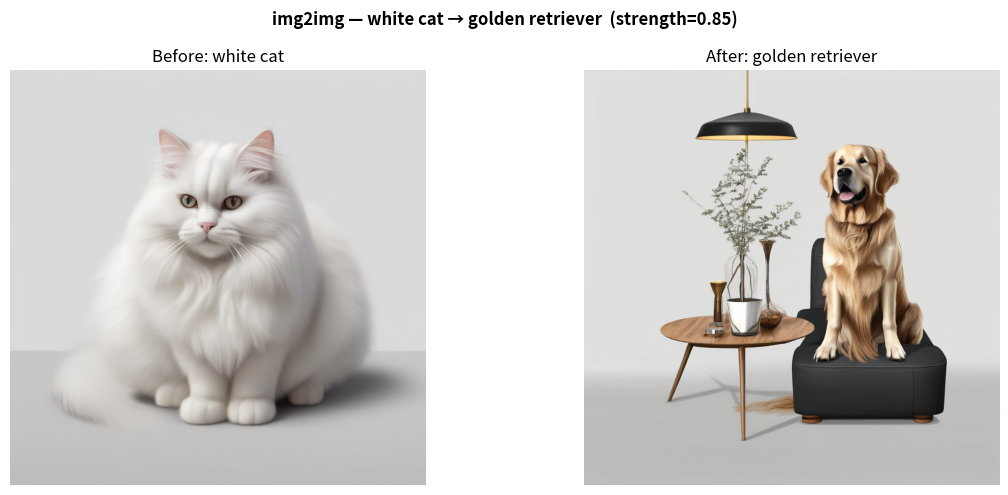

In [17]:
# strength を 0.85 に上げて，形・色ともに大きく変化させる

prompt_white_cat = "a fluffy white cat sitting in front of a black sofa, photorealistic, high quality"
prompt_dog = "a golden retriver sitting in front of a black sofa, photorealistic, high quality"

# Step1: 白猫の元画像を生成
dummy_img = Image.new("RGB", (1024, 1024), color=(200, 200, 200))
print("元画像（白猫）を生成中...")
src_white_cat = img2img_pipe(
    prompt=prompt_white_cat,
    image=dummy_img,
    num_inference_steps=30,
    strength=0.99,
    guidance_scale=7.5,
).images[0]

# Step2: strength=0.85 でゴールデン・レトリバーに変換（高めに設定して変化を大きく）
print("img2img で犬に変換中... (strength=0.85)")
out_dog = img2img_pipe(
    prompt=prompt_dog,
    negative_prompt="cat, white fur, feline",
    image=src_white_cat,
    strength=0.85,
    guidance_scale=8.0,
).images[0]

save_image(src_white_cat,  "task2_i2i_ex1_before.png")
save_image(out_dogr, "task2_i2i_ex1_after.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(src_white_cat);  axes[0].set_title("Before: white cat");  axes[0].axis("off")
axes[1].imshow(out_dog); axes[1].set_title("After: golden retriever");   axes[1].axis("off")
plt.suptitle("img2img — white cat → golden retriever  (strength=0.85)", fontweight="bold")
plt.tight_layout(); plt.show()

### 例2：赤いリンゴ → 黄色いバナナ

元画像（赤いリンゴ）を生成中...


100%|██████████| 29/29 [00:15<00:00,  1.85it/s]


img2img でバナナに変換中... (strength=0.85)


100%|██████████| 42/42 [00:22<00:00,  1.87it/s]


  保存完了: out/task2_i2i_ex2_before.png
  保存完了: out/task2_i2i_ex2_after.png


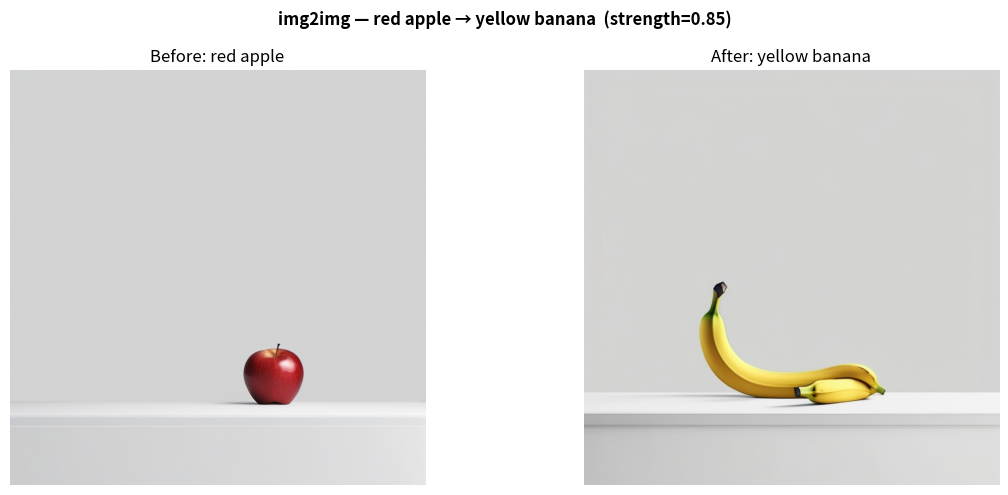

In [18]:
prompt_apple  = "a single red apple on a white table, centered, photorealistic, high quality"
prompt_banana = "a single yellow banana on a white table, centered, photorealistic, high quality"

# Step1: リンゴの元画像を生成
dummy_img = Image.new("RGB", (1024, 1024), color=(200, 200, 200))
print("元画像（赤いリンゴ）を生成中...")
src_apple = img2img_pipe(
    prompt=prompt_apple,
    image=dummy_img,
    num_inference_steps=30,
    strength=0.99,
    guidance_scale=7.5,
).images[0]

# Step2: strength=0.85 でバナナに変換
print("img2img でバナナに変換中... (strength=0.85)")
out_banana = img2img_pipe(
    prompt=prompt_banana,
    negative_prompt="apple, red fruit, round",
    image=src_apple,
    strength=0.85,
    guidance_scale=8.0,
).images[0]

save_image(src_apple,  "task2_i2i_ex2_before.png")
save_image(out_banana, "task2_i2i_ex2_after.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(src_apple);  axes[0].set_title("Before: red apple");   axes[0].axis("off")
axes[1].imshow(out_banana); axes[1].set_title("After: yellow banana"); axes[1].axis("off")
plt.suptitle("img2img — red apple → yellow banana  (strength=0.85)", fontweight="bold")
plt.tight_layout(); plt.show()

### img2img まとめ比較

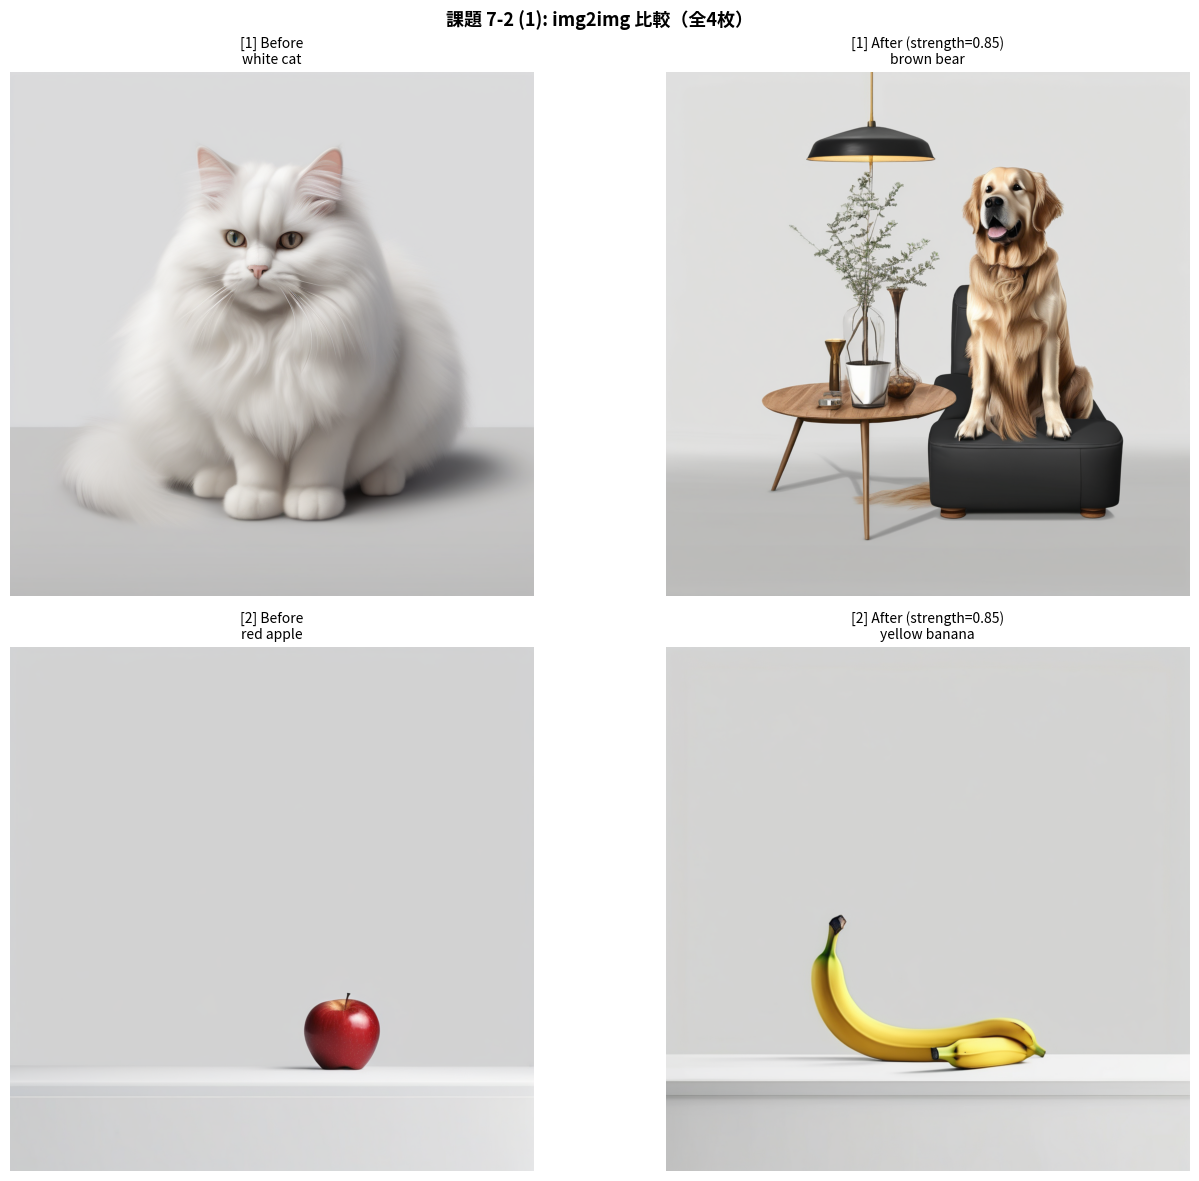

In [19]:
# ─── 2画像をまとめて4枚グリッドで比較表示 ───
imgs_i2i = [
    Image.open(OUTDIR / "task2_i2i_ex1_before.png").convert("RGB"),
    Image.open(OUTDIR / "task2_i2i_ex1_after.png").convert("RGB"),
    Image.open(OUTDIR / "task2_i2i_ex2_before.png").convert("RGB"),
    Image.open(OUTDIR / "task2_i2i_ex2_after.png").convert("RGB"),
]
titles_i2i = [
    "[1] Before\nwhite cat",
    "[1] After (strength=0.85)\nbrown bear",
    "[2] Before\nred apple",
    "[2] After (strength=0.85)\nyellow banana",
]
show_grid(imgs_i2i, titles=titles_i2i, cols=2, figsize=(14, 12),
          suptitle="課題 7-2 (1): img2img 比較（全4枚）")

---
# 課題 7-2 (2)　マスク画像で指定部分を書き換え（Inpainting）

**Inpainting** では，元画像に加えて **マスク画像**（白＝書き換え領域，黒＝保持領域）を指定することで，
画像の特定部分だけをプロンプトの内容で置き換えます．

### 実施内容
| No | 元画像 | マスク形状 | 書き換え内容 |
|---|---|---|---|
| 1 | 白猫 | 猫の部分 | 犬に変更 |
| 2 | 赤いリンゴ | リンゴ部分 | バナナに変更 |


In [20]:
# ─── Inpainting パイプのロード ───
# img2img パイプを先に解放してからロード
clear_gpu(img2img_pipe)

print("Inpainting パイプをロード中...")
inpaint_pipe = AutoPipelineForInpainting.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=DTYPE,
    variant="fp16" if DEVICE == "cuda" else None,
    cache_dir=os.environ["HF_HOME"],
    token=True,
)
# メモリ節約の設定
inpaint_pipe.enable_attention_slicing()
if hasattr(inpaint_pipe, 'enable_vae_slicing'):
    inpaint_pipe.enable_vae_slicing()
inpaint_pipe.enable_model_cpu_offload()
print("準備完了")

Inpainting パイプをロード中...


Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.02it/s]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLInpaintPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


準備完了


### 1：猫を犬に変更）

元画像サイズ: 1024 x 1024
マスクの最大値: 255  （255なら白がある）
マスクの最小値: 0  （0なら黒がある）


/tmp/ipykernel_2594735/1497362172.py:20: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print(f"マスクの最大値: {max(mask_dog.getdata())}  （255なら白がある）")
/tmp/ipykernel_2594735/1497362172.py:21: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print(f"マスクの最小値: {min(mask_dog.getdata())}  （0なら黒がある）")


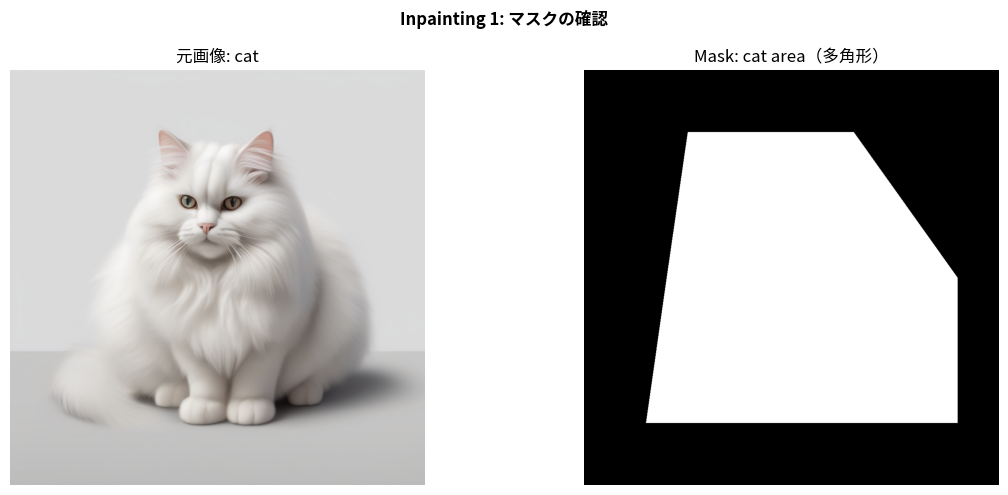

In [38]:
# 猫の画像読み込み
src_dog = Image.open(
    "out/task2_i2i_ex1_before.png"
).convert("RGB")

W, H = src_dog.size
print(f"元画像サイズ: {W} x {H}")

# 多角形マスクで猫の体を囲む（中央部分）
points_dog = [
    (int(W*0.25), int(H*0.15)),
    (int(W*0.65), int(H*0.15)),
    (int(W*0.90), int(H*0.50)),
    (int(W*0.90), int(H*0.85)),
    (int(W*0.15), int(H*0.85)),
    (int(W*0.20), int(H*0.50)),
]
mask_dog = make_polygon_mask((W, H), points_dog)

print(f"マスクの最大値: {max(mask_dog.getdata())}  （255なら白がある）")
print(f"マスクの最小値: {min(mask_dog.getdata())}  （0なら黒がある）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(src_dog);               axes[0].set_title("元画像: cat"); axes[0].axis("off")
axes[1].imshow(mask_dog, cmap="gray"); axes[1].set_title("Mask: cat area（多角形）"); axes[1].axis("off")
plt.suptitle("Inpainting 1: マスクの確認", fontweight="bold")
plt.tight_layout(); plt.show()


Inpainting 実行中（猫 → 犬）...


100%|██████████| 39/39 [00:20<00:00,  1.92it/s]


  保存完了: out/task2_inpaint_ex1_before.png
  保存完了: out/task2_inpaint_ex1_mask.png
  保存完了: out/task2_inpaint_ex1_after.png


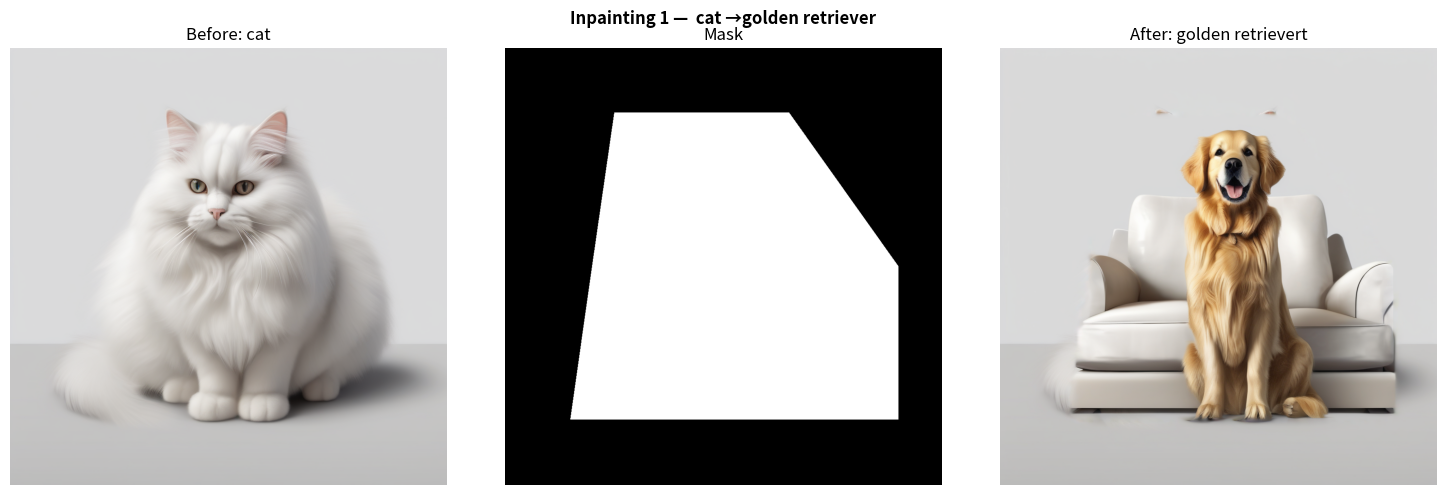

In [39]:
# ─── Inpainting 実行: 猫 → 犬 ───
inpaint_prompt_dog = (
    "a golden retriever dog sitting sitting in front of a sofa, "
    "photorealistic, high quality"
)

print("Inpainting 実行中（猫 → 犬）...")
out_cat = inpaint_pipe(
    prompt=inpaint_prompt_dog,
    image=src_dog,
    mask_image=mask_dog,
    num_inference_steps=40,
    guidance_scale=8.0,
).images[0]

save_image(src_dog,  "task2_inpaint_ex1_before.png")
save_image(mask_dog, "task2_inpaint_ex1_mask.png")
save_image(out_cat,  "task2_inpaint_ex1_after.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(src_dog);               axes[0].set_title("Before: cat"); axes[0].axis("off")
axes[1].imshow(mask_dog, cmap="gray"); axes[1].set_title("Mask");                   axes[1].axis("off")
axes[2].imshow(out_cat);               axes[2].set_title("After: golden retrievert");  axes[2].axis("off")
plt.suptitle("Inpainting 1 —  cat →golden retriever", fontweight="bold")
plt.tight_layout(); plt.show()


### 2：リンゴをバナナに変更

元画像サイズ: 1024 x 1024
マスクの最大値: 255  （255なら白がある）
マスクの最小値: 0  （0なら黒がある）


/tmp/ipykernel_2594735/1983266091.py:15: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print(f"マスクの最大値: {max(mask_center.getdata())}  （255なら白がある）")
/tmp/ipykernel_2594735/1983266091.py:16: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print(f"マスクの最小値: {min(mask_center.getdata())}  （0なら黒がある）")


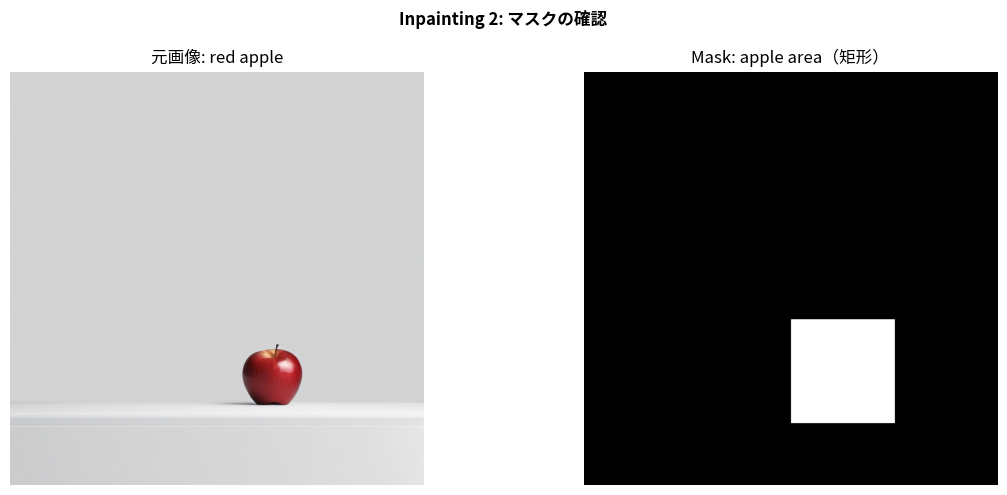

In [43]:
# リンゴの画像を読み込み
src_apple2 = Image.open(
    "out/task2_i2i_ex2_before.png"
).convert("RGB")

W, H = src_apple2.size
print(f"元画像サイズ: {W} x {H}")

# 中央の矩形マスクでリンゴ部分を指定
mask_center = make_rect_mask(
    (W, H),
    box=(int(W*0.50), int(H*0.60), int(W*0.75), int(H*0.85))
)

print(f"マスクの最大値: {max(mask_center.getdata())}  （255なら白がある）")
print(f"マスクの最小値: {min(mask_center.getdata())}  （0なら黒がある）")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(src_apple2);              axes[0].set_title("元画像: red apple");       axes[0].axis("off")
axes[1].imshow(mask_center, cmap="gray"); axes[1].set_title("Mask: apple area（矩形）"); axes[1].axis("off")
plt.suptitle("Inpainting 2: マスクの確認", fontweight="bold")
plt.tight_layout(); plt.show()


Inpainting 実行中（リンゴ → バナナ）...


100%|██████████| 39/39 [00:20<00:00,  1.88it/s]


  保存完了: out/task2_inpaint_ex2_before.png
  保存完了: out/task2_inpaint_ex2_mask.png
  保存完了: out/task2_inpaint_ex2_after.png


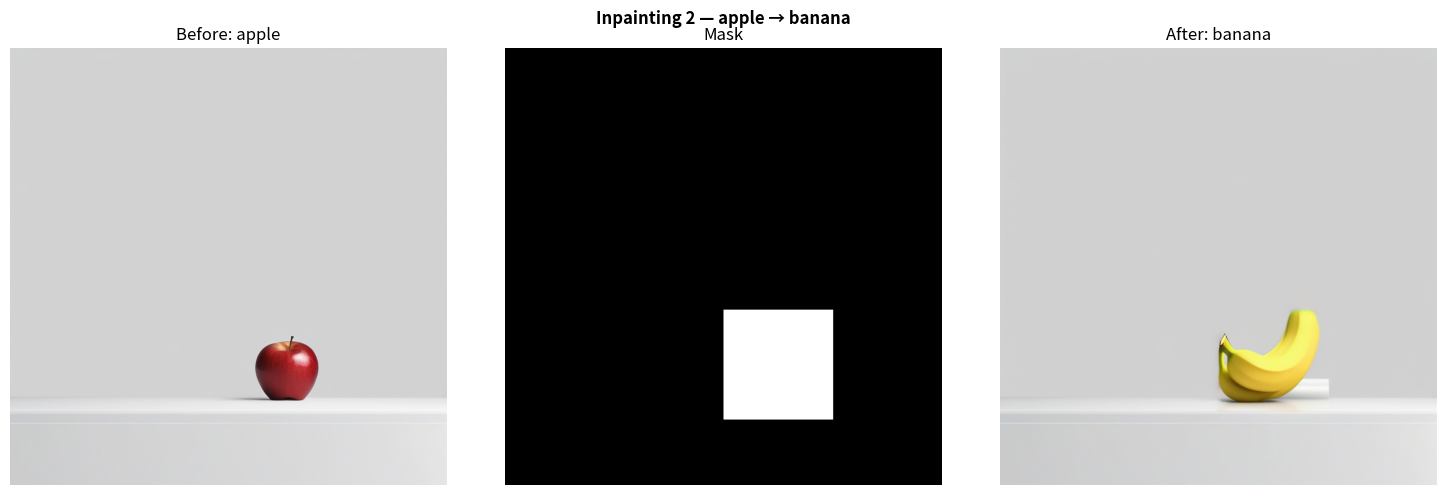

In [48]:
# ─── Inpainting 実行: リンゴ → バナナ ───
inpaint_prompt_banana = (
    "a single yellow banana on a white table,"
    "photorealistic, high quality"
)

print("Inpainting 実行中（リンゴ → バナナ）...")
out_banana = inpaint_pipe(
    prompt=inpaint_prompt_banana,
    image=src_apple2,
    mask_image=mask_center,
    num_inference_steps=40,
    guidance_scale=8.0,
).images[0]

save_image(src_apple2,   "task2_inpaint_ex2_before.png")
save_image(mask_center, "task2_inpaint_ex2_mask.png")
save_image(out_banana,  "task2_inpaint_ex2_after.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(src_apple2);               axes[0].set_title("Before: apple"); axes[0].axis("off")
axes[1].imshow(mask_center, cmap="gray"); axes[1].set_title("Mask");                axes[1].axis("off")
axes[2].imshow(out_banana);              axes[2].set_title("After: banana"); axes[2].axis("off")
plt.suptitle("Inpainting 2 — apple → banana", fontweight="bold")
plt.tight_layout(); plt.show()


### Inpainting まとめ比較

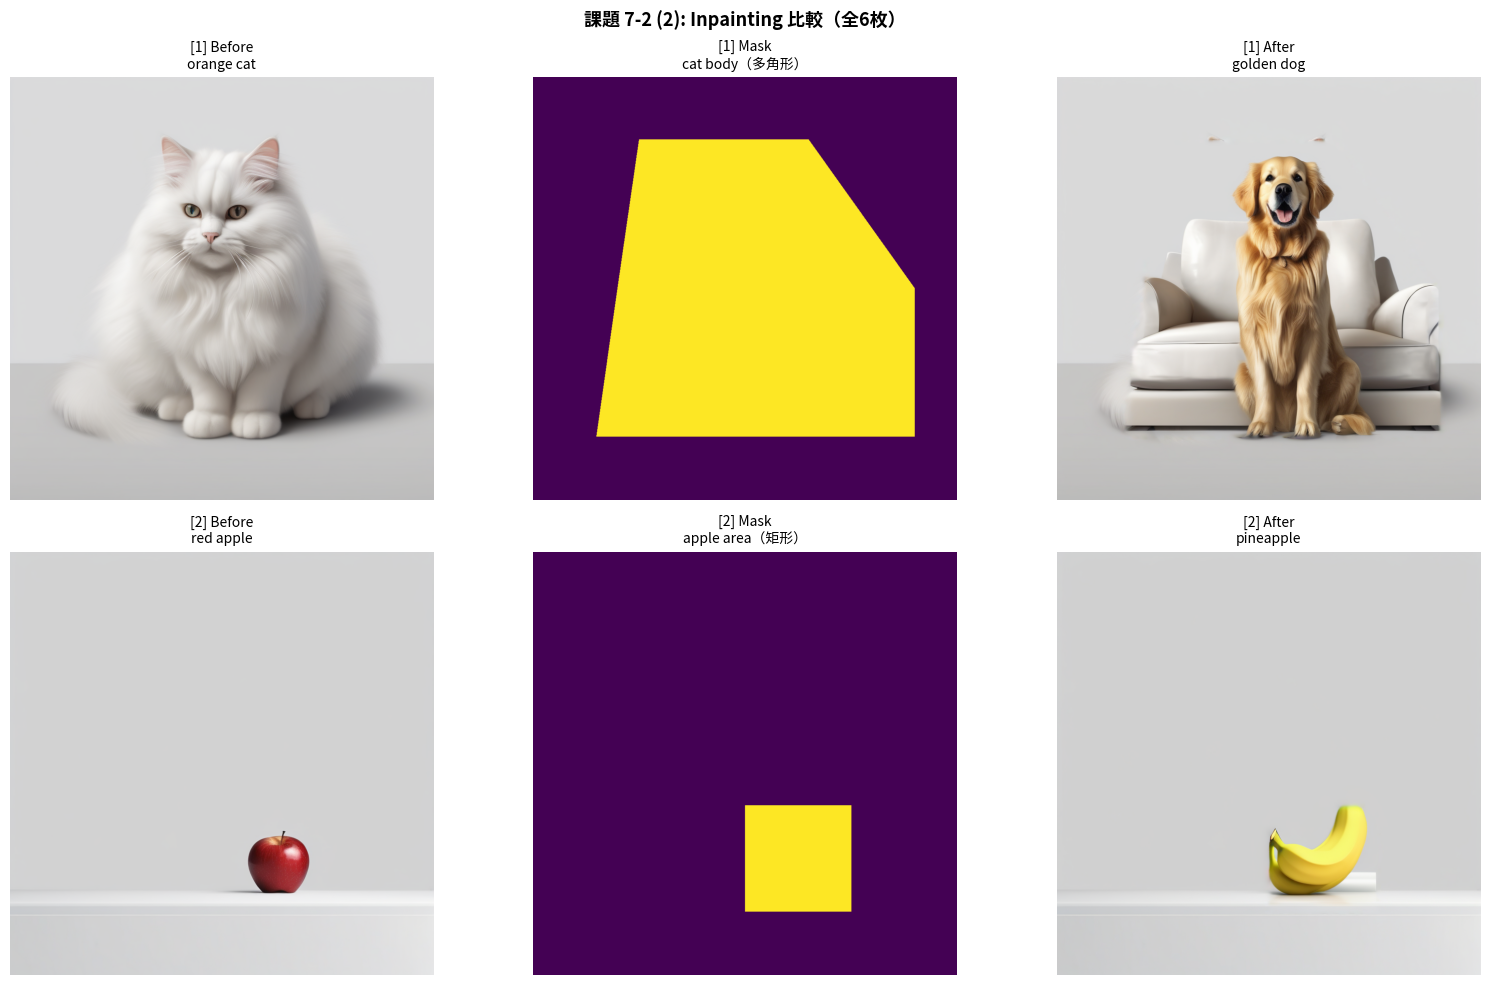

In [49]:
# ─── まとめて6枚グリッドで比較表示 ───
imgs_inp = [
    Image.open(OUTDIR / "task2_inpaint_ex1_before.png").convert("RGB"),
    Image.open(OUTDIR / "task2_inpaint_ex1_mask.png").convert("L"),
    Image.open(OUTDIR / "task2_inpaint_ex1_after.png").convert("RGB"),
    Image.open(OUTDIR / "task2_inpaint_ex2_before.png").convert("RGB"),
    Image.open(OUTDIR / "task2_inpaint_ex2_mask.png").convert("L"),
    Image.open(OUTDIR / "task2_inpaint_ex2_after.png").convert("RGB"),
]
titles_inp = [
    "[1] Before\norange cat",
    "[1] Mask\ncat body（多角形）",
    "[1] After\ngolden dog",
    "[2] Before\nred apple",
    "[2] Mask\napple area（矩形）",
    "[2] After\npineapple",
]
show_grid(imgs_inp, titles=titles_inp, cols=3, figsize=(16, 10),
          suptitle="課題 7-2 (2): Inpainting 比較（全6枚）")


In [50]:
# ─── 後片付け：GPU メモリを解放 ───
clear_gpu(inpaint_pipe, img2img_pipe)
print("すべての処理が完了しました。")

すべての処理が完了しました。
